# Bayes Net Inference

## Inference
- Def - calculating some useful quantity from a joint probability distribution.
- Examples:
  - Posterior Probability:
    - $P(Q \mid E_1 = e_1, \dots, E_k = e_k)$
      - `Q` - query variable; set of variables whose probability you want to know
      - `E` - all of the E's are the evidence.
    - Most likely explaination:
      - Instead of wanting the full probability distribution over Q, often wan the single most probable assignment of Q given the evidence.
      - $\arg\max_q \, P(Q = q \mid E_1 = e_1, \dots)$
        - returns the best q that gives the highest posterior probability.
      - Ex.
        - $\arg\max_q \, P(\text{sick} = q \mid \text{cough}=\text{yes}, \text{fever}=\text{yes})$
- $P(Q \mid E_1 = e_1, \dots, E_k = e_k) = \frac{1}{Z} \cdot P(Q,e_1...e_k)$
- *Enumeration (in this context)* - exhaustive process of looking at the entire joint probability distribution and summing up specific rows to match the query.

### Inference by Enumeration in Bayes' Net
- Given unlimited time, inference in BNs is easy.
  - We obviosuly don't have unlimited time.



## Inference by Enumeration vs. Variable Elimination
- Inference by enumeration is so slow because you join up a whole joint distribtion before you sum out the hidden variables.
- Variable Elimination
  - interleaves joining and marginalizing (summing) - mizing them together in sequence to be much faster than multiplying all of the factors and them marginalizing (enumeration)


## Factor Objects
- Note the number of capitals in a selected joint like P(x,Y) represent the dimensionality of the table.
  - Sums to P(x)
- A family of conditionals P(X|Y) with multiple conditionals has a table in which the sum of the probabilities = |X|
- P(y|X) sums to '... who knows'
- In General when we write $P(Y_1...Y_n|X_1...X_M)$
  - it is a *factor* - a multi-dimensional array
  - Its values are $P(y_1...y_n|x_1...x_M)$
  - Any assigned (=lower-case) X or Y is a dimension missing (selected) from the array.


## Inference by Enumeration Procedural Outline
- Track objects called factors (above)
- Initial factors are local CPTs (one per node)
- Any known values are selected and CPT are edited.
- THen join all factors, Eliminate, Normalize.

### Operation 1: Joining Factors
- Exactly like a DB join
- Quide literally Joining together nodes and CTPs in a Bayes' Net
- Get all factors over the joining variable.
- Build new factor over the union of the variables involved.
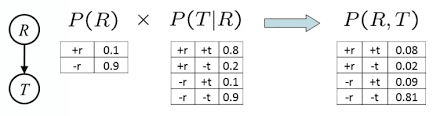
- Point wise product: $\forall r,t: P(r,t) = P(r) \cdot P(t|r)$
- You can chain multiple joins:  
- 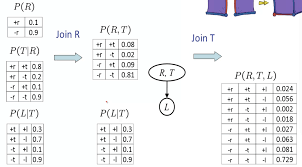



### Operation 2: Eliminate
- Eliminate aka marginalization
- Taking out a factor and summing out a variable
  - Shrinks a factor to a smaller one.
  - A *projection* operation (like database)

**Initial Factor**  
**P(R, T, L)**  
*(Variables: R, T, L)*

| R   | T   | L   | Probability |
|-----|-----|-----|-------------|
| +r  | +t  | +l  | 0.024       |
| +r  | +t  | -l  | 0.056       |
| +r  | -t  | +l  | 0.002       |
| +r  | -t  | -l  | 0.018       |
| -r  | +t  | +l  | 0.027       |
| -r  | +t  | -l  | 0.063       |
| -r  | -t  | +l  | 0.081       |
| -r  | -t  | -l  | 0.729       |

**↓ Sum out R**  
*(Eliminate variable R → remaining variables: T, L)*

**P(T, L)**

| T   | L   | Probability |
|-----|-----|-------------|
| +t  | +l  | 0.051       |
| +t  | -l  | 0.119       |
| -t  | +l  | 0.083       |
| -t  | -l  | 0.747       |

**↓ Sum out T**  
*(Eliminate variable T → remaining variable: L)*

**P(L)**

| L   | Probability |
|-----|-------------|
| +l  | 0.134       |
| -l  | 0.886       |



**Visual Flow (Node Reduction):**

(R, T, L)  
→ **Sum out R** → (T, L)  
→ **Sum out T** → (L)






### Recap of Inference by Enumeration
- So as shown above, we can do multiple joins, then multiple eliminations
- What variable elimination is, is interleaving those in for increased efficiency.  


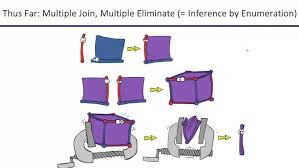

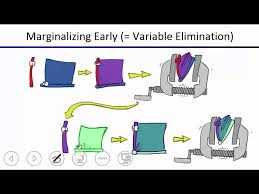

## Variable Elimination in Depth

**Bayesian Network Structure:**

```
      R
      ↓
      T
      ↓
      L
```

**Query:**  
**P(L) = ?**
`
#### Inference by Enumeration

$$
P(L) = \sum_t \sum_r P(L|t) \, P(r) \, P(t|r)
$$

**Order of Operations (Enumeration):**

- Join on r  
- Join on t  
- Eliminate r  
- Eliminate t  

*(All joins are performed first, followed by all eliminations)*

#### Variable Elimination

$$
P(L) = \sum_t P(L|t) \left( \sum_r P(r) \, P(t|r) \right)
$$

**Order of Operations (Variable Elimination):**

- Join on r  
- Eliminate r  
- Join on t  
- Eliminate t  

*(Interleaves joining and eliminating — eliminates r immediately after joining the factors that involve it)*
